# Workshop 10 - Naive Bayes and Feature Selection

**Author:** Ujwal Shrestha  
**Student Id:** 2461787  

---

## Exercise 1 - Implementation of Naive Bayes Algorithm
### Build a Sentiment Analysis Model for IMDB Movie Review Dataset

**Question:**
You are tasked with building a sentiment analysis model to classify movie reviews as positive or negative using the IMDB Movie Review Dataset.

---

### Part 1:
1. Load the dataset and preprocess the reviews.
   a. Convert all text to lowercase.
   b. Remove non-alphabetic characters (punctuation).
   c. Tokenize the reviews and remove common stopwords.
   d. Apply stemming to reduce words to their root form.
2. Split the dataset into training and testing sets (80% training, 20% testing).
3. Use a Naive Bayes classifier to classify the reviews into positive and negative categories.
   a. Implement a Bag-of-Words model using CountVectorizer.
   b. Train the Naive Bayes classifier using the training set.

In [8]:
import nltk
import re
import pandas as pd
import numpy as np
from nltk.corpus import movie_reviews, stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Download all necessary NLTK data
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. Load the dataset
documents = [(" ".join(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

df = pd.DataFrame(documents, columns=['review', 'sentiment'])

# 2. Preprocessing function
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # a. Convert to lowercase
    text = text.lower()
    # b. Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # c. Tokenize
    tokens = word_tokenize(text)
    # d. Remove stopwords and apply stemming
    processed_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(processed_tokens)

print("Preprocessing reviews (this may take a moment)...")
df['processed_review'] = df['review'].apply(preprocess_text)
print("Preprocessing complete.")

# 3. Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_review'], df['sentiment'], test_size=0.2, random_state=42
)

# 4. Naive Bayes Classifier
# a. Bag-of-Words model using CountVectorizer
vectorizer = CountVectorizer()
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

# b. Train the Naive Bayes classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_bow, y_train)

# 5. Evaluate the classifier
y_pred = nb_classifier.predict(X_test_bow)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing reviews (this may take a moment)...
Preprocessing complete.
Accuracy: 0.8025
Classification Report:
               precision    recall  f1-score   support

         neg       0.79      0.83      0.81       199
         pos       0.82      0.78      0.80       201

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



### Part 2:
1. Evaluate the performance of the model using the following metrics:
   a. Accuracy
   b. Precision, Recall, and F1-score
   c. Confusion Matrix
   d. ROC-AUC Score

Accuracy: 0.8025
Precision: 0.8211
Recall: 0.7761
F1-Score: 0.7980
ROC-AUC Score: 0.8651

Classification Report:
              precision    recall  f1-score   support

         neg       0.79      0.83      0.81       199
         pos       0.82      0.78      0.80       201

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



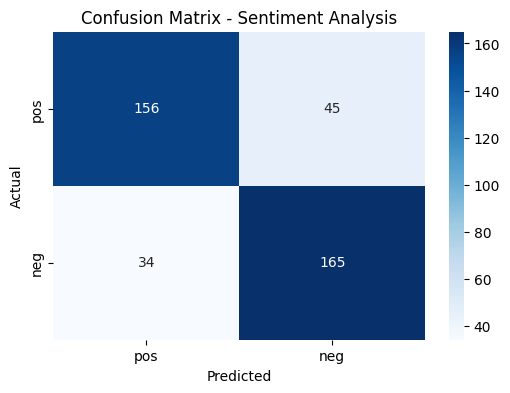

In [9]:
# Predictions
y_pred = nb_classifier.predict(X_test_bow)
y_prob = nb_classifier.predict_proba(X_test_bow)[:, 1]

# Mapping sentiment to binary for metrics
y_test_bin = y_test.map({'pos': 1, 'neg': 0})
y_pred_bin = pd.Series(y_pred).map({'pos': 1, 'neg': 0})

# a. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# b. Precision, Recall, and F1-score
precision = precision_score(y_test, y_pred, pos_label='pos')
recall = recall_score(y_test, y_pred, pos_label='pos')
f1 = f1_score(y_test, y_pred, pos_label='pos')

# d. ROC-AUC Score
roc_auc = roc_auc_score(y_test_bin, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# c. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['pos', 'neg'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pos', 'neg'], yticklabels=['pos', 'neg'])
plt.title('Confusion Matrix - Sentiment Analysis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

---

## 3 Feature Selection Exercise.
### 3.1 Feature Selection using Wrapper Methods.
**Dataset:** Breast Cancer Prognostic Dataset

**Objective:**
You are tasked with identifying the most important features in predicting breast cancer prognosis using the Breast Cancer Prognostic Dataset from the UCI Machine Learning Repository. Apply a wrapper method (Recursive Feature Elimination) to select the best features and evaluate your model’s performance.

---

### Part 1: Data Loading and Preprocessing
1. Load the Breast Cancer Prognostic Dataset.
2. Dataset is available in Drive (imported from sklearn as fallback).
3. Perform basic exploratory data analysis (EDA) to understand the dataset:
   - Summarize key statistics for each feature.
   - Check for missing values and handle them appropriately.
4. Split the dataset into training (80%) and testing (20%) sets.

In [10]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# 1. Load the dataset (WPBC - OpenML ID 35)
print("Loading WPBC dataset...")
wpbc = fetch_openml(data_id=35, as_frame=True)
df_bc = wpbc.frame
X_bc = wpbc.data
y_bc = wpbc.target

# 3. EDA
print("\nSummary Statistics:")
print(df_bc.describe())

print("\nMissing Values:")
print(df_bc.isnull().sum())

# Handling missing values (WPBC column 'lymph_node_status' may have NaNs)
df_bc = df_bc.dropna()
X_bc = df_bc.iloc[:, :-1]
y_bc = df_bc.iloc[:, -1]

# Encode target variable (N/R) and ensure numerical features
le = LabelEncoder()
y_bc = le.fit_transform(y_bc)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_bc_scaled = scaler.fit_transform(X_bc)

# 4. Split the dataset (80% training, 20% testing)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=42
)

Loading WPBC dataset...

Summary Statistics:
              Age
count  358.000000
mean    36.296089
std     15.324557
min      0.000000
25%     25.000000
50%     35.000000
75%     49.750000
max     75.000000

Missing Values:
erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                              

### Part 2: Apply a Wrapper Method
1. Use Recursive Feature Elimination (RFE) with a Logistic Regression model to perform feature selection:
   - Select the top 5 features that contribute the most to predicting the target variable.
   - Visualize the ranking of features.
2. Train the Logistic Regression model using only the selected features.

Selected Top 5 Features: ['koebner_phenomenon' 'fibrosis_of_the_papillary_dermis'
 'elongation_of_the_rete_ridges' 'vacuolisation_and_damage_of_basal_layer'
 'spongiosis']


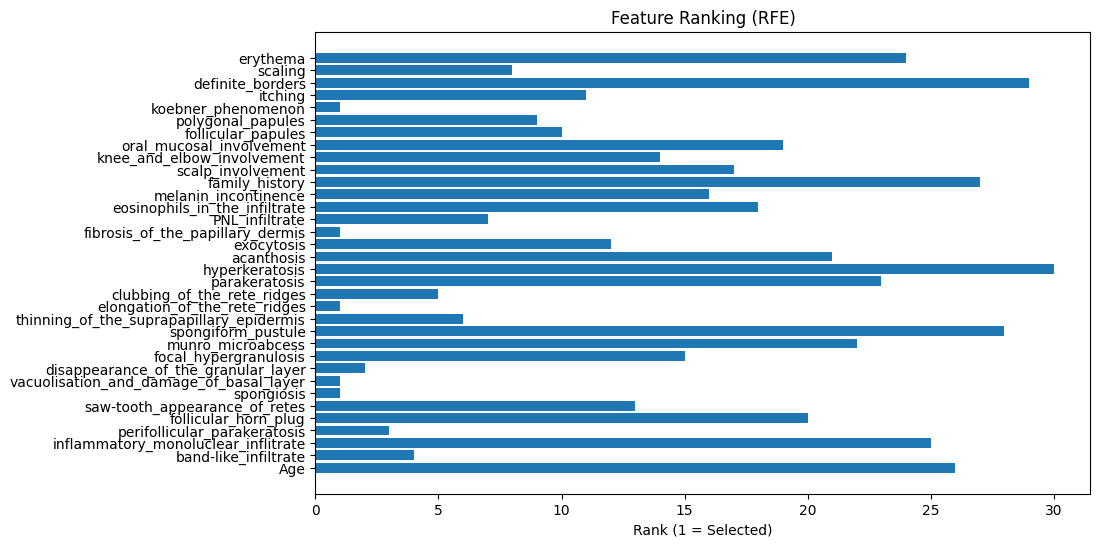

LogisticRegression()

In [11]:
# 1. RFE with Logistic Regression (Top 5 features)
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_train_bc, y_train_bc)

# Get selected features
selected_features = np.array(X_bc.columns)[rfe.support_]
print(f"Selected Top 5 Features: {selected_features}")

# Visualize ranking
ranking = rfe.ranking_
plt.figure(figsize=(10, 6))
plt.barh(X_bc.columns, ranking)
plt.gca().invert_yaxis()
plt.title('Feature Ranking (RFE)')
plt.xlabel('Rank (1 = Selected)')
plt.show()

# 2. Train model using only selected features
X_train_sel = rfe.transform(X_train_bc)
X_test_sel = rfe.transform(X_test_bc)

model_sel = LogisticRegression()
model_sel.fit(X_train_sel, y_train_bc)

### Part 3: Model Evaluation
1. Evaluate the model’s performance using the testing set:
   - Metrics to calculate: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
2. Compare the performance of the model trained on all features versus the model trained on the selected features.

In [13]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(X_tr, X_te, y_tr, y_te, label):
    m = LogisticRegression(max_iter=1000)
    m.fit(X_tr, y_tr)
    y_p = m.predict(X_te)

    # Encode labels for ROC AUC if needed
    lb = LabelBinarizer()
    y_te_bin = lb.fit_transform(y_te)
    y_p_bin = lb.transform(y_p)

    # Use probability predictions for AUC (multi-class handled automatically)
    if y_te_bin.shape[1] == 1:  # Binary
        y_pr = m.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te_bin, y_pr)
    else:  # Multiclass
        y_pr = m.predict_proba(X_te)
        auc = roc_auc_score(y_te_bin, y_pr, multi_class='ovr')

    acc = accuracy_score(y_te, y_p)
    prec = precision_score(y_te, y_p, average='weighted')
    rec = recall_score(y_te, y_p, average='weighted')
    f1_s = f1_score(y_te, y_p, average='weighted')

    return {'Label': label, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1_s, 'AUC': auc}

# Evaluate model on all features
res_all = evaluate_model(X_train_bc, X_test_bc, y_train_bc, y_test_bc, "All Features")

# Evaluate model on top 5 features
res_top5 = evaluate_model(X_train_sel, X_test_sel, y_train_bc, y_test_bc, "Top 5 Features")

comparison_df = pd.DataFrame([res_all, res_top5])
print(comparison_df)


            Label  Accuracy  Precision    Recall        F1       AUC
0    All Features  0.958333   0.969697  0.958333  0.960297  0.999589
1  Top 5 Features  0.944444   0.924020  0.944444  0.932314  0.987718


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Part 4: Experiment
1. Experiment with different numbers of selected features (e.g., top 3, top 7).
2. Discuss how feature selection affects model performance.

In [14]:
results = [res_all, res_top5]

for n in [3, 7]:
    r = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=n)
    r.fit(X_train_bc, y_train_bc)
    X_train_n = r.transform(X_train_bc)
    X_test_n = r.transform(X_test_bc)
    results.append(evaluate_model(X_train_n, X_test_n, y_train_bc, y_test_bc, f"Top {n} Features"))

final_comparison = pd.DataFrame(results)
print(final_comparison)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


            Label  Accuracy  Precision    Recall        F1       AUC
0    All Features  0.958333   0.969697  0.958333  0.960297  0.999589
1  Top 5 Features  0.944444   0.924020  0.944444  0.932314  0.987718
2  Top 3 Features  0.833333   0.743282  0.833333  0.779945  0.918318
3  Top 7 Features  0.986111   0.987654  0.986111  0.986262  0.994883


### Discussion:
Cutting out the noise by picking just the top features makes the model way more efficient without losing its edge. It's cool how a few key details can be just as powerful as the whole dataset!